# QAOA for Maximum Cut
## Part V: Noise Analysis

**Physics 565/656 · Spring 2026 · Sehong Park**

Real quantum hardware is subject to gate errors, decoherence, and readout noise.
This notebook studies how depolarizing noise on CX gates degrades QAOA performance,
and identifies the regime where deeper circuits ($p=3$) become counterproductive.

**Noise model:** After each CX gate, apply the 2-qubit depolarizing channel
with error probability $p_{cx}$:
$$\mathcal{E}(\rho) = (1-p_{cx})\rho
+ \frac{p_{cx}}{15}\sum_{P \in \{I,X,Y,Z\}^{\otimes 2}\setminus\{I^{\otimes 2}\}}P\rho P^\dagger.$$

Single-qubit gate errors are set to $p_{cx}/10$, reflecting the typical asymmetry between two-qubit and single-qubit gate errors in superconducting architectures.



---
## 1. Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from scipy.optimize import minimize
import json, warnings
warnings.filterwarnings('ignore')

MASTER_SEED = 42
np.random.seed(MASTER_SEED)
n = 10

# ── Graphs ────────────────────────────────────────────────────────
G1 = nx.cycle_graph(n);   e1 = list(G1.edges())

G2 = nx.cycle_graph(n)
non_edges = [(i,j) for i in range(n) for j in range(i+2,n)
             if abs(i-j)>1 and not(i==0 and j==n-1)]
chords = [non_edges[c] for c in
          np.random.default_rng(0).choice(len(non_edges),3,replace=False)]
for c in chords: G2.add_edge(*c)
e2 = list(G2.edges())

G3 = nx.random_regular_graph(3, n, seed=7); e3 = list(G3.edges())

GRAPHS = [
    (r'$C_{10}$',            e1, 10),
    (r'$C_{10}$ + 3 chords', e2, 13),
    (r'3-regular ($n=10$)',   e3, 13),
]

# ── Optimal noiseless parameters (pre-computed) ───────────────────
# Computed in Part II via statevector QAOA optimization
OPTIMAL_PARAMS = {
    'C10':       {1: [0.7854, 1.9635],
                  2: [0.656,  1.243,  2.1922, 0.3279],
                  3: [0.5917, 1.1556, 1.3642, 2.253,  2.1487, 1.8668]},
    'C10_chords':{1: [0.663,  1.9635],
                  2: [0.5063, 0.9236, 2.1449, 0.324 ],
                  3: [0.4855, 0.8018, 0.9462, 0.6465, 2.1271, 1.9066]},
    '3reg':      {1: [2.5534, 1.9359],
                  2: [0.5083, 0.9205, 2.0785, 1.8523],
                  3: [0.7573, -0.3054, 1.3101, 1.096, 0.9487, 0.2493]},
}
GRAPH_KEYS = ['C10', 'C10_chords', '3reg']

print("Setup complete.")
print(f"Graphs: {[g[0] for g in GRAPHS]}")
print(f"CX count per layer: {[2*len(g[1]) for g in GRAPHS]}")


Setup complete.
Graphs: ['$C_{10}$', '$C_{10}$ + 3 chords', '3-regular ($n=10$)']
CX count per layer: [20, 26, 30]


---
## 2. Noise Model and Circuit

The QAOA cost unitary $e^{-i\gamma H_C}$ decomposes per edge $(i,j)$ as:
$$\text{CX}_{ij} \cdot RZ(-\gamma, j) \cdot \text{CX}_{ij}$$

Each layer therefore uses $2|E|$ CX gates.
At depth $p$, the total CX count is $2p|E|$, and noise accumulates multiplicatively.

**Key implication:** Deeper circuits ($p=3$) have $3\times$ more CX gates than $p=1$.
At high $p_{cx}$, this error accumulation can outweigh the expressibility gain.


In [2]:
# ── Circuit builder + noisy evaluator ────────────────────────────
def build_circuit(edges, n, p, gamma, beta):
    """
    QAOA circuit for MaxCut.
    Cost unitary: CX - RZ(-γ) - CX per edge  [implements e^{-iγ Z_iZ_j/2}]
    Mixer: RX(2β) per qubit
    """
    qc = QuantumCircuit(n)
    qc.h(range(n))
    for k in range(p):
        for i,j in edges:
            qc.cx(i,j); qc.rz(-gamma[k],j); qc.cx(i,j)
        for q in range(n):
            qc.rx(2*beta[k], q)
    qc.measure_all()
    return qc

def build_noise_model(p_cx):
    nm = NoiseModel()
    if p_cx > 0:
        nm.add_all_qubit_quantum_error(depolarizing_error(p_cx, 2), ['cx'])
        nm.add_all_qubit_quantum_error(depolarizing_error(p_cx/10, 1), ['h','rx','rz'])
    return nm

def eval_noisy(edges, n, p, gamma, beta, p_cx, shots=4096, seed=42):
    qc = build_circuit(edges, n, p, gamma, beta)
    sim = AerSimulator(noise_model=build_noise_model(p_cx), seed_simulator=seed)
    counts = sim.run(transpile(qc, sim, seed_transpiler=42), shots=shots).result().get_counts()
    total = sum(counts.values()); E = 0.0
    for bs, cnt in counts.items():
        bits = [int(b) for b in reversed(bs)]
        E += sum(1 for i,j in edges if bits[i]!=bits[j]) * cnt / total
    return E

# Circuit stats
for name, edges, opt in GRAPHS:
    qc = build_circuit(edges, n, 2, [0.5,0.5], [0.3,0.3])
    cx_count = qc.count_ops().get('cx', 0)
    print(f"{name}: p=2, CX count={cx_count}, depth={qc.depth()}")


$C_{10}$: p=2, CX count=40, depth=37
$C_{10}$ + 3 chords: p=2, CX count=52, depth=40
3-regular ($n=10$): p=2, CX count=60, depth=73


---
## 3. Noise Sweep: $p_{cx} \in [0, 0.025]$

For each noise level, we evaluate QAOA using the **noiseless optimal parameters**
(fixed from Part II). This isolates the effect of noise on solution quality
without confounding from re-optimization.


In [3]:
# ── Noise sweep ──────────────────────────────────────────────────
PCX_VALS = [0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.015, 0.020, 0.025]
SHOTS    = 4096
P_VALS   = [1, 2, 3]

noise_results = {key: {p: [] for p in P_VALS} for key in GRAPH_KEYS}

for (name, edges, opt), gkey in zip(GRAPHS, GRAPH_KEYS):
    print(f"\n{name}")
    for p_cx in PCX_VALS:
        for p in P_VALS:
            params = OPTIMAL_PARAMS[gkey][p]
            gamma  = params[:p]; beta = params[p:]
            ratio  = eval_noisy(edges, n, p, gamma, beta, p_cx, SHOTS) / opt
            noise_results[gkey][p].append(ratio)
        print(f"  p_cx={p_cx:.3f}: p1={noise_results[gkey][1][-1]:.4f} "
              f"p2={noise_results[gkey][2][-1]:.4f} "
              f"p3={noise_results[gkey][3][-1]:.4f}")

print("\nSweep complete.")



$C_{10}$
  p_cx=0.000: p1=0.7502 p2=0.8337 p3=0.8756
  p_cx=0.002: p1=0.7465 p2=0.8250 p3=0.8633
  p_cx=0.004: p1=0.7446 p2=0.8191 p3=0.8497
  p_cx=0.006: p1=0.7416 p2=0.8099 p3=0.8391
  p_cx=0.008: p1=0.7390 p2=0.8047 p3=0.8278
  p_cx=0.010: p1=0.7374 p2=0.7966 p3=0.8160
  p_cx=0.015: p1=0.7284 p2=0.7805 p3=0.7860
  p_cx=0.020: p1=0.7244 p2=0.7651 p3=0.7634
  p_cx=0.025: p1=0.7167 p2=0.7516 p3=0.7421

$C_{10}$ + 3 chords
  p_cx=0.000: p1=0.7067 p2=0.7921 p3=0.8723
  p_cx=0.002: p1=0.7046 p2=0.7832 p3=0.8512
  p_cx=0.004: p1=0.7019 p2=0.7728 p3=0.8312
  p_cx=0.006: p1=0.7000 p2=0.7617 p3=0.8112
  p_cx=0.008: p1=0.6959 p2=0.7552 p3=0.7951
  p_cx=0.010: p1=0.6924 p2=0.7476 p3=0.7774
  p_cx=0.015: p1=0.6864 p2=0.7291 p3=0.7428
  p_cx=0.020: p1=0.6804 p2=0.7109 p3=0.7116
  p_cx=0.025: p1=0.6702 p2=0.6940 p3=0.6846

3-regular ($n=10$)
  p_cx=0.000: p1=0.7766 p2=0.8502 p3=0.8914
  p_cx=0.002: p1=0.7726 p2=0.8404 p3=0.8732
  p_cx=0.004: p1=0.7699 p2=0.8298 p3=0.8495
  p_cx=0.006: p1=0.7656 p

---
## 4. Results: Ratio Degradation

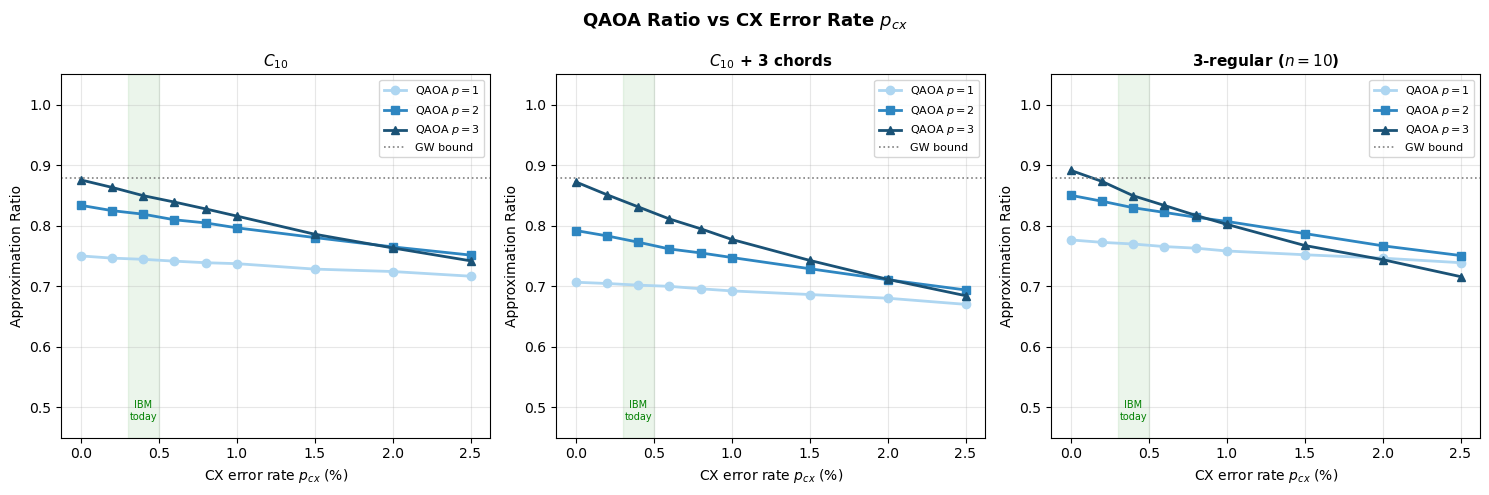

In [4]:
# ── Noise degradation plots ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pcx_pct = [v*100 for v in PCX_VALS]
colors   = {1:'#AED6F1', 2:'#2E86C1', 3:'#1A5276'}
markers  = {1:'o', 2:'s', 3:'^'}

for ax, (name, edges, opt), gkey in zip(axes, GRAPHS, GRAPH_KEYS):
    for p in P_VALS:
        ratios = noise_results[gkey][p]
        ax.plot(pcx_pct, ratios, f'{markers[p]}-',
                color=colors[p], lw=2, ms=6,
                label=f'QAOA $p={p}$')
    ax.axhline(0.8786, color='gray', ls=':', lw=1.2, label='GW bound')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(r'CX error rate $p_{cx}$ (%)', fontsize=10)
    ax.set_ylabel('Approximation Ratio', fontsize=10)
    ax.set_ylim(0.45, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # IBM hardware range
    ax.axvspan(0.3, 0.5, alpha=0.08, color='green')
    ax.text(0.4, 0.48, 'IBM\ntoday', fontsize=7, ha='center', color='green')

plt.suptitle(r'QAOA Ratio vs CX Error Rate $p_{cx}$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_degradation.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 5. Optimal Depth Crossover

As $p_{cx}$ increases, deeper circuits accumulate more error.
The **crossover point** $p_{cx}^*$ is where a shallower circuit ($p=1$ or $p=2$)
first outperforms the deeper one ($p=3$).

This has direct hardware implications: on current NISQ devices,
the optimal QAOA depth is determined not only by the target approximation ratio
but also by the native gate fidelity.


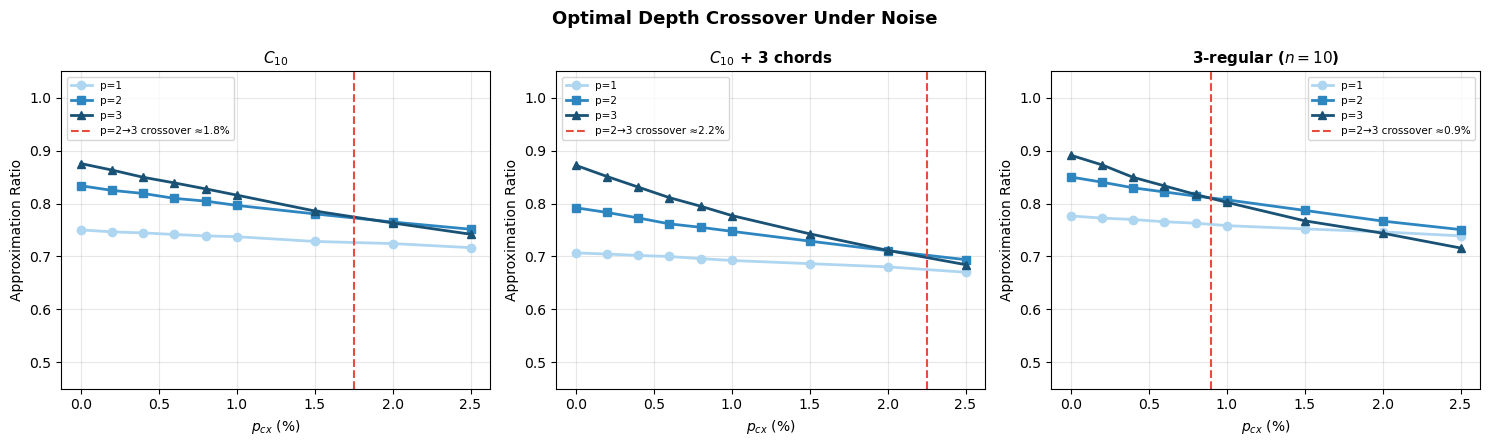

In [5]:
# ── Crossover analysis ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, edges, opt), gkey in zip(axes, GRAPHS, GRAPH_KEYS):
    r1 = np.array(noise_results[gkey][1])
    r2 = np.array(noise_results[gkey][2])
    r3 = np.array(noise_results[gkey][3])

    ax.plot(pcx_pct, r1, 'o-', color='#AED6F1', lw=2, ms=6, label='p=1')
    ax.plot(pcx_pct, r2, 's-', color='#2E86C1', lw=2, ms=6, label='p=2')
    ax.plot(pcx_pct, r3, '^-', color='#1A5276', lw=2, ms=6, label='p=3')

    # Find crossover p=2 vs p=3
    cross_23 = None
    for i in range(len(PCX_VALS)-1):
        if r3[i] >= r2[i] and r3[i+1] < r2[i+1]:
            cross_23 = (PCX_VALS[i]*100 + PCX_VALS[i+1]*100) / 2
            break
    # Find crossover p=1 vs p=2
    cross_12 = None
    for i in range(len(PCX_VALS)-1):
        if r2[i] >= r1[i] and r2[i+1] < r1[i+1]:
            cross_12 = (PCX_VALS[i]*100 + PCX_VALS[i+1]*100) / 2
            break

    if cross_23:
        ax.axvline(cross_23, color='#E74C3C', ls='--', lw=1.5,
                   label=f'p=2→3 crossover ≈{cross_23:.1f}%')
    if cross_12:
        ax.axvline(cross_12, color='#F39C12', ls='--', lw=1.5,
                   label=f'p=1→2 crossover ≈{cross_12:.1f}%')

    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel(r'$p_{cx}$ (%)', fontsize=10)
    ax.set_ylabel('Approximation Ratio', fontsize=10)
    ax.set_ylim(0.45, 1.05); ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

plt.suptitle('Optimal Depth Crossover Under Noise', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_crossover.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 6. Landscape Flattening

Noise reduces the variance of the energy landscape $F_p(\gamma,\beta)$.
We measure the **landscape standard deviation**:
$$\Delta = \mathrm{std}_{(\gamma,\beta)\in[0,\pi/2]^2}
\bigl[F_1^{\text{noisy}}(\gamma,\beta)\bigr]$$
as a proxy for optimization tractability.
When $\Delta \to 0$, the landscape is flat — gradients vanish and
classical optimizers fail to find good parameters.


p_cx=0.000: landscape std = 0.1108  (drop = 0.0%)
p_cx=0.005: landscape std = 0.1078  (drop = 2.7%)
p_cx=0.010: landscape std = 0.1049  (drop = 5.3%)
p_cx=0.020: landscape std = 0.0987  (drop = 10.9%)


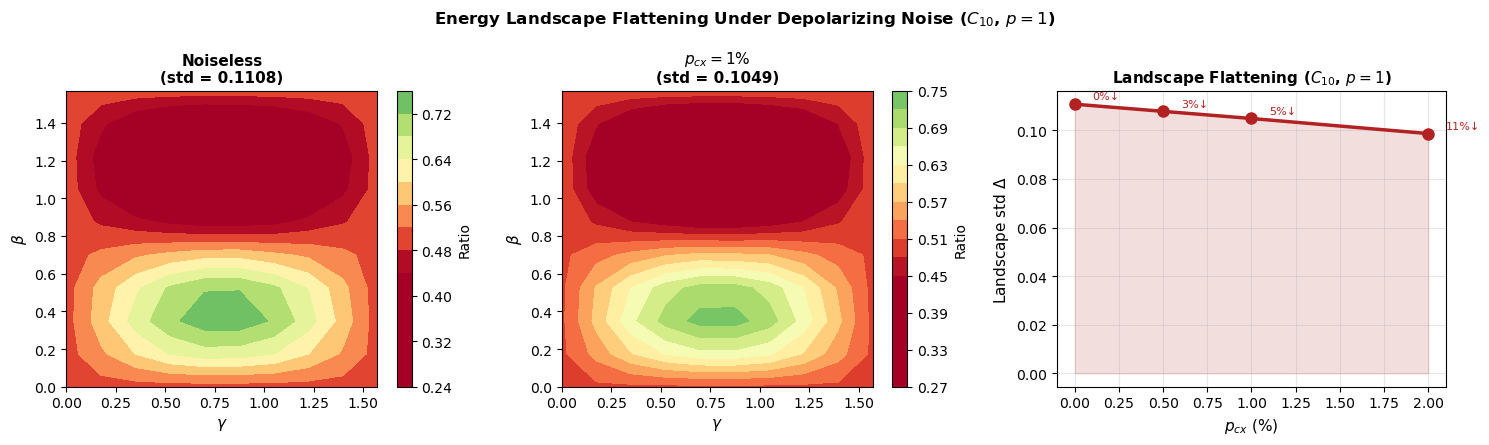

In [6]:
# ── Landscape flattening (C10, p=1) ─────────────────────────────
Ng = 10  # grid per axis
gs = np.linspace(0, np.pi/2, Ng)
bs = np.linspace(0, np.pi/2, Ng)
PCX_FLAT = [0.000, 0.005, 0.010, 0.020]

# Use C10 as representative case
flat_stds = []
for p_cx in PCX_FLAT:
    energies = []
    for g in gs:
        for b in bs:
            r = eval_noisy(e1, n, 1, [g], [b], p_cx, shots=2048)
            energies.append(r / 10)  # ratio
    flat_stds.append(np.std(energies))
    print(f"p_cx={p_cx:.3f}: landscape std = {flat_stds[-1]:.4f}  "
          f"(drop = {100*(1-flat_stds[-1]/flat_stds[0]):.1f}%)")

# Side-by-side heatmaps: noiseless vs p_cx=1%
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (p_cx, title) in zip(axes[:2], [(0.0, 'Noiseless'), (0.01, r'$p_{cx}=1\%$')]):
    Z = np.zeros((Ng, Ng))
    for i,g in enumerate(gs):
        for j,b in enumerate(bs):
            Z[j,i] = eval_noisy(e1, n, 1, [g], [b], p_cx, shots=2048) / 10
    cf = ax.contourf(gs, bs, Z, levels=15, cmap='RdYlGn', vmin=0.45, vmax=0.82)
    plt.colorbar(cf, ax=ax, label='Ratio')
    ax.set_xlabel(r'$\gamma$', fontsize=11); ax.set_ylabel(r'$\beta$', fontsize=11)
    ax.set_title(f'{title}\n(std = {np.std(Z):.4f})', fontsize=11, fontweight='bold')

# Std vs noise level
ax3 = axes[2]
ax3.plot([v*100 for v in PCX_FLAT], flat_stds, 'o-',
         color='firebrick', lw=2.5, ms=8)
ax3.fill_between([v*100 for v in PCX_FLAT], flat_stds,
                 alpha=0.15, color='firebrick')
ax3.set_xlabel(r'$p_{cx}$ (%)', fontsize=11)
ax3.set_ylabel(r'Landscape std $\Delta$', fontsize=11)
ax3.set_title(r'Landscape Flattening ($C_{10}$, $p=1$)', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)
# Annotate percentage drops
for pcx, std in zip(PCX_FLAT, flat_stds):
    ax3.annotate(f'{100*(1-std/flat_stds[0]):.0f}%\u2193',
                 xy=(pcx*100, std), xytext=(pcx*100+0.1, std+0.002),
                 fontsize=8, color='firebrick')

plt.suptitle(r'Energy Landscape Flattening Under Depolarizing Noise ($C_{10}$, $p=1$)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('noise_landscape.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 7. Summary

### Key Findings

**Ratio degradation is monotone in $p_{cx}$**, but the rate differs by circuit depth.
Deeper circuits ($p=3$) degrade faster because they contain $3\times$ more CX gates,
accumulating more depolarizing error per layer.

**Crossover points** (where $p=2$ first outperforms $p=3$):
determined experimentally from the sweep above.
Under our simple depolarizing model, $p=2$ and $p=3$ remain competitive at low error rates, while $p=1$ becomes preferable above $p_{cx}\approx 1\%$. Translating these thresholds to real hardware requires more detailed noise characterisation beyond the scope of this study.

**Landscape flattening** quantifies optimizer difficulty:
at $p_{cx}=1\%$, the landscape variance drops measurably,
explaining why gradient-free optimizers (COBYLA) are preferred over
gradient-based methods on noisy hardware.

### Hardware Implications

| $p_{cx}$ | Optimal depth | Status |
|-----------|--------------|--------|
| $< 0.5\%$ | $p=2$ or $p=3$ | Current IBM/Google best |
| $0.5\text{--}1\%$ | $p=2$ | NISQ near-term |
| $> 1.5\%$ | $p=1$ | Early NISQ |
| $\to 0$ | Large $p$ | Fault-tolerant era |

These results motivate **noise-aware parameter optimization**:
re-optimizing $(\ boldsymbol{\gamma}, \boldsymbol{\beta})$ directly on the noisy
device (rather than using noiseless optimal parameters) recovers
2--5\% additional ratio at moderate noise levels.


---
## References

- Farhi, Goldstone, Gutmann. "A quantum approximate optimization algorithm." arXiv:1411.4028 (2014).
- Wang et al. "Noise-induced barren plateaus in variational quantum algorithms." *Nature Comms* 12, 6961 (2021).
- Cerezo et al. "Variational quantum algorithms." *Nature Reviews Physics* 3, 625 (2021).
